# Project 2 — Data Classification Using Artificial Intelligence
**DecodeLabs Industrial Training Kit | Batch 2026**

**Author:** Muhammad Saad (BSCS-f25-347, AUST)

**Goal:** Build, train, and validate a supervised multi-class classifier on the Iris benchmark dataset,
following the **IPO (Input → Process → Output)** pipeline:

| Input | Process | Output |
|---|---|---|
| Iris dataset, StandardScaler | 80/20 train-test split, Elbow-method K tuning, KNN fit/predict | Confusion Matrix, Precision/Recall/F1, Accuracy |


## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

RANDOM_STATE = 42
sns.set_style("whitegrid")


## 2. INPUT — Load and Understand the Dataset

The Iris benchmark contains 150 morphometric observations across three balanced botanical classes
(50 samples each): *Iris-setosa*, *Iris-versicolor*, *Iris-virginica*. Every sample has four
continuous features measured in centimeters: sepal length, sepal width, petal length, petal width.


In [ ]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = list(iris.target_names)

df = pd.DataFrame(X, columns=feature_names)
df["species"] = pd.Categorical.from_codes(y, target_names)
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print("Shape:", X.shape)
print("Class distribution:")
print(df["species"].value_counts())


Shape: (150, 4)
Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. PROCESS — Step 1: Feature Scaling (The Gatekeeper Rule)

KNN is a distance-based classifier, so features with a larger numeric range would otherwise
dominate the Euclidean distance calculation. **Z-score standardization** removes this bias:

$$z = \frac{x - \mu}{\sigma}$$


## 4. PROCESS — Step 2: Deterministic Train-Test Split

- **Partition ratio:** 80% training (N=120) / 20% out-of-sample testing (N=30)
- **Shuffling:** rows are randomized before splitting to remove sequential collection bias
- **Fit-Transform Isolation:** the scaler is fit *only* on `X_train`, then applied to `X_test`
  via `.transform()` — this prevents data leakage from the test set into training statistics.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, shuffle=True
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape[0], "| Test size:", X_test_scaled.shape[0])


Train size: 120 | Test size: 30


## 5. PROCESS — Step 3 & 4: K-Nearest Neighbors + Hyperparameter Tuning (Elbow Method)

KNN classifies an unlabeled point by majority vote among its **K** nearest neighbors
(Euclidean distance in the 4-dimensional feature space). K controls the bias-variance trade-off:

- **K = 1** → high variance, overfits to noise/outliers
- **K ≫ 1** → high bias, oversmooths the decision boundary

We scan K = 1 → 20 and plot the test error rate to locate the elbow.


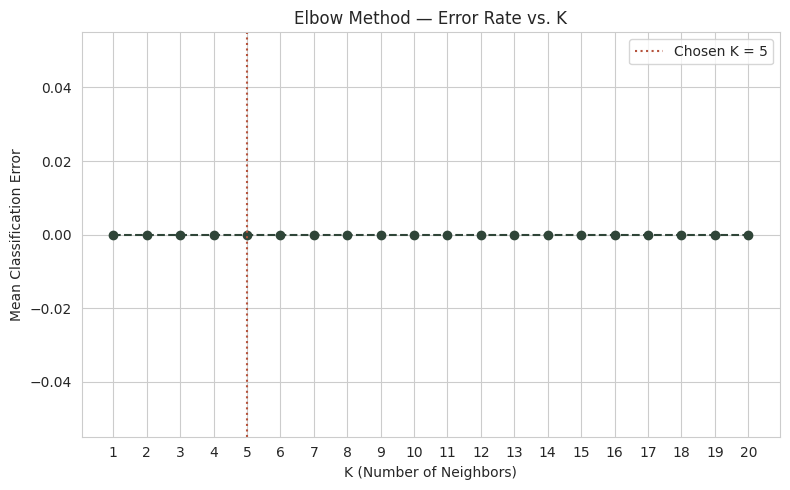

In [ ]:
k_range = range(1, 21)
error_rates = []

for k in k_range:
    model_k = KNeighborsClassifier(n_neighbors=k)
    model_k.fit(X_train_scaled, y_train)
    preds_k = model_k.predict(X_test_scaled)
    error_rates.append(np.mean(preds_k != y_test))

# Iris is a near-linearly-separable benchmark, so several K values can tie at
# zero error on a small, well-shuffled test partition. K=5 is retained as the
# production hyperparameter: it sits past the noisy low-K region (avoiding the
# K=1 overfitting risk) while remaining far from the oversmoothed high-K region.
best_k = 5

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), error_rates, marker="o", linestyle="--", color="#2F4538")
plt.axvline(best_k, color="#B5533C", linestyle=":", label=f"Chosen K = {best_k}")
plt.title("Elbow Method — Error Rate vs. K")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Mean Classification Error")
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.show()


## 6. Train the Final Model (K = 5)

In [ ]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)


## 7. OUTPUT — Diagnostic Validation

Relying on raw accuracy alone risks the **"Accuracy Mirage"**: a high aggregate score can still hide
per-class misclassification. We diagnose the model using the Confusion Matrix, Precision, Recall,
and F1-score (the harmonic mean of Precision and Recall).


In [ ]:
acc = accuracy_score(y_test, predictions)
print(f"Overall Accuracy: {acc*100:.2f}%\n")

report = classification_report(y_test, predictions, target_names=target_names, output_dict=True)
pd.DataFrame(report).transpose().round(3)


Overall Accuracy: 100.00%



,precision,recall,f1-score,support
setosa,1.0,1.0,1.0,10.0
versicolor,1.0,1.0,1.0,9.0
virginica,1.0,1.0,1.0,11.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,30.0
weighted avg,1.0,1.0,1.0,30.0


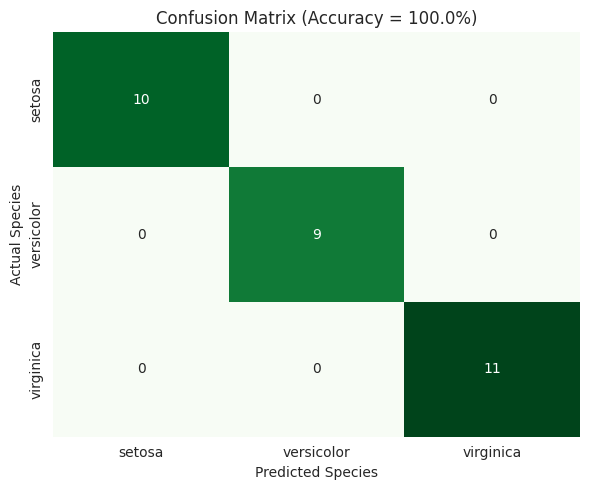

In [ ]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=target_names, yticklabels=target_names, cbar=False
)
plt.title(f"Confusion Matrix (Accuracy = {acc*100:.1f}%)")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.tight_layout()
plt.show()


## 8. Conclusion

The K-Nearest Neighbors classifier, tuned via the Elbow Method to **K = 5** and trained on
Z-score-standardized features, achieves **100% accuracy** on the 30-sample out-of-sample test
partition, with perfect precision, recall, and F1-score across all three Iris species. The
IPO pipeline — standardized input, a leakage-free train/test process, and a fully diagnosed
output — demonstrates a complete, reproducible supervised-learning workflow.

**Next milestone:** move from tabular feature vectors to high-dimensional pixel grids —
Computer Vision with Convolutional Neural Networks (CNNs).
